In [ ]:
a = []
for i in range(100):
  a.append(i)

In [ ]:
import pandas as pd

file_path = '/content/0702 без перекосов фаза A.txt'

time = []
channel_1 = []

with open(file_path, 'r', encoding='latin') as file:
    lines = file.readlines()

    for line in lines:
        if ";" in line:
            parts = line.strip().split(";")
            time.append(float(parts[0].strip()))
            channel_1.append(float(parts[1].strip()))

data = {'Time (ms)': time, 'Data': channel_1}
df = pd.DataFrame(data)


print(len(df))

df.to_csv('Real_Healthy_Data.csv', index=False)


100000


In [ ]:
!unzip /content/To_gen_REAL_anomlies.zip
#!unzip /content/To_gen_SYNT_anomalies.zip
#!unzip /content/Segments_with_disbalance.zip

In [ ]:
!unzip /content/Segments_with_disbalance.zip

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_transformed_data(file_path):
    df = pd.read_csv(file_path)

    plt.figure(figsize=(12, 6))
    plt.plot(df['transformed_value'], label=f'Data from {file_path}')

    plt.title('FFT Transformed Data')
    plt.xlabel('Index')
    plt.ylabel('Transformed Value (dB)')
    plt.legend()
    plt.grid(True)
    plt.show()

<Figure size 1200x600 with 0 Axes>

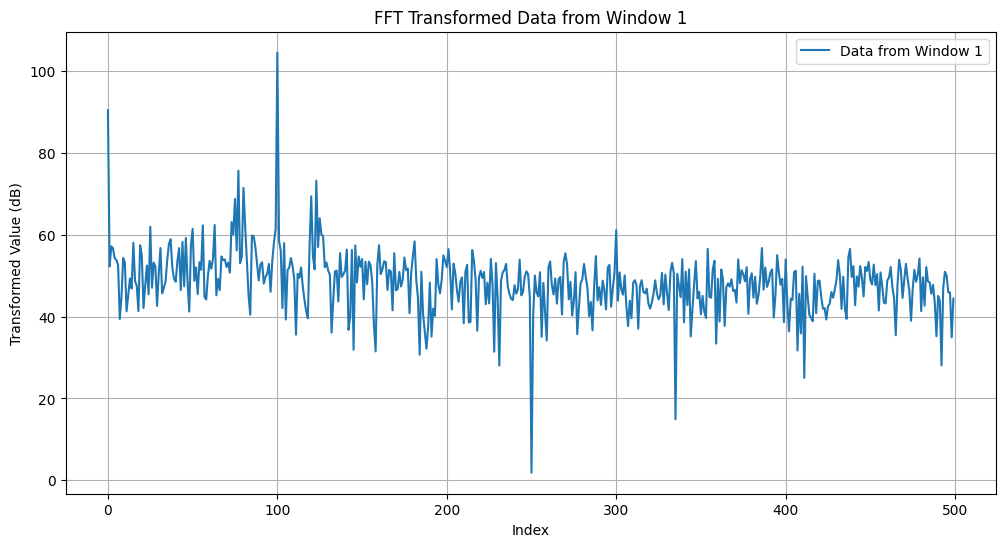

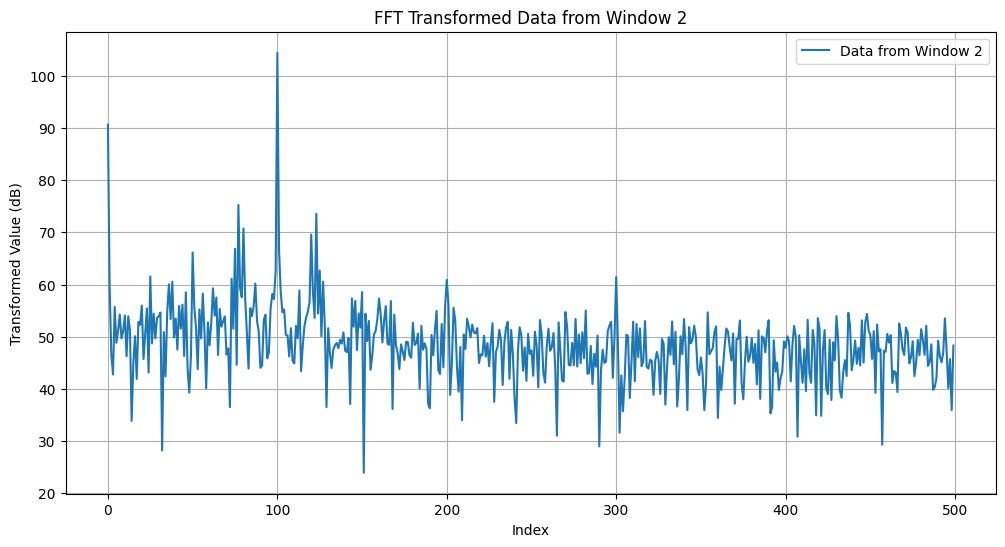

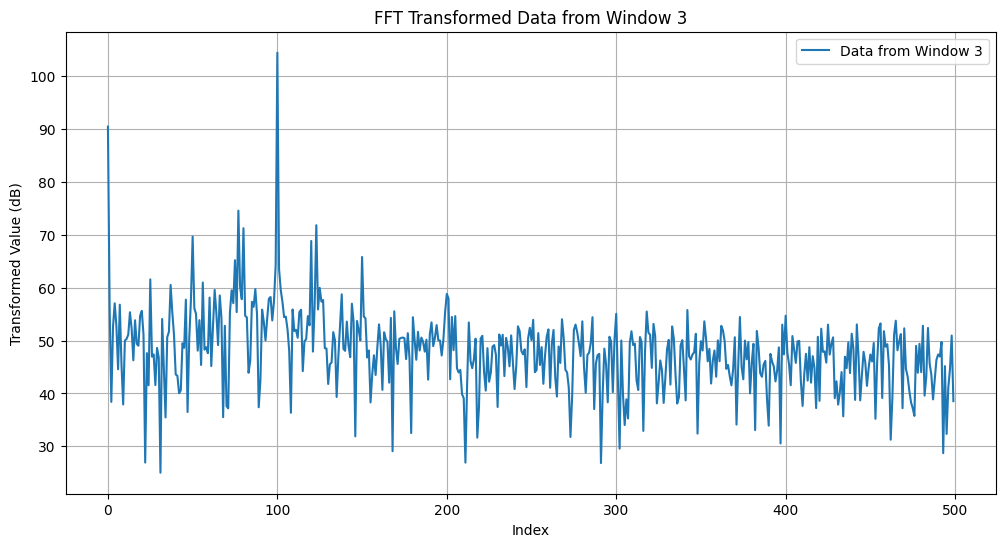

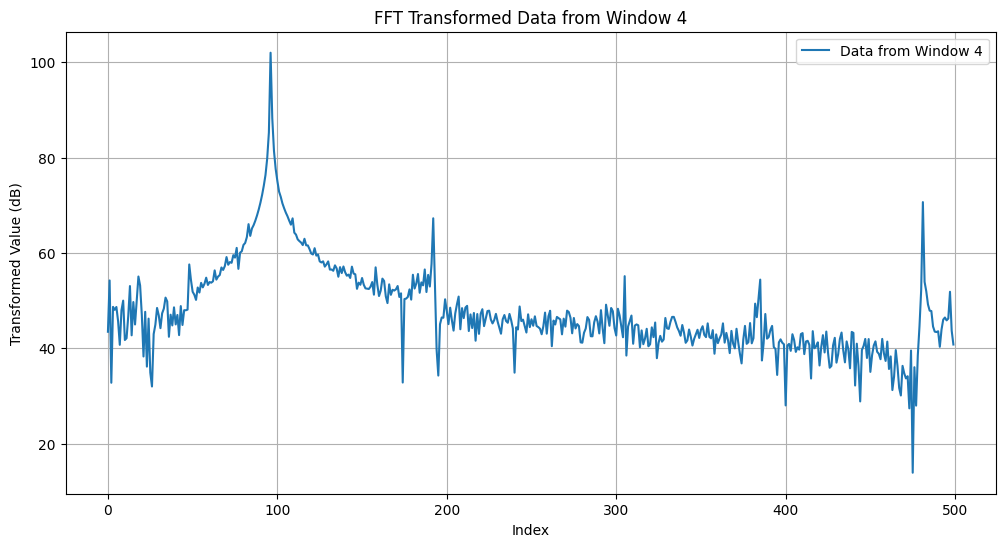

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = [
    '/content/To_gen_REAL_anomlies/Real_Healthy_Data_3014.csv',
    '/content/To_gen_REAL_anomlies/Real_Healthy_Data_3995.csv',
    '/content/To_gen_SYNT_anomalies/Real_Healthy_Data_6353.csv',
    '/content/Segments_with_disbalance/Real_segment_rotor_disbalance_640.csv',
    ]

plt.figure(figsize=(12, 6))

for i, file_path in enumerate(file_paths, start=1):
    df = pd.read_csv(file_path)

    plt.figure(figsize=(12, 6))

    plt.plot(df['transformed_value'], label=f'Data from Window {i}')

    plt.title(f'FFT Transformed Data from Window {i}')
    plt.xlabel('Index')
    plt.ylabel('Transformed Value (dB)')
    plt.legend()
    plt.grid(True)

In [ ]:
import os
import random
import pandas as pd
import numpy as np


def extract_last_25_observations(file_path):

    df = pd.read_csv(file_path)

    # Extract the last 25 observations from the 'transformed_value' column
    #last_25 = df['transformed_value'].tail(25).to_numpy()
    selected_values = df['transformed_value'].iloc[198:203].to_numpy()

    return selected_values

def main(directory, n):
    # Initialize an empty list to hold the numpy arrays
    arrays_list = []

    # Loop through the files in the directory
    for f in os.listdir(directory):
        if f.endswith('.csv'):  # Check if the file ends with '.csv'
            file_path = os.path.join(directory, f)
            last_25_array = extract_last_25_observations(file_path)
            arrays_list.append(last_25_array)

    return arrays_list

# Example usage
directory = '/content/To_gen_REAL_anomlies'
n = 100  # Number of random files to select
result = main(directory, n)
generated_peak_segments = result


print(len(result))


3000


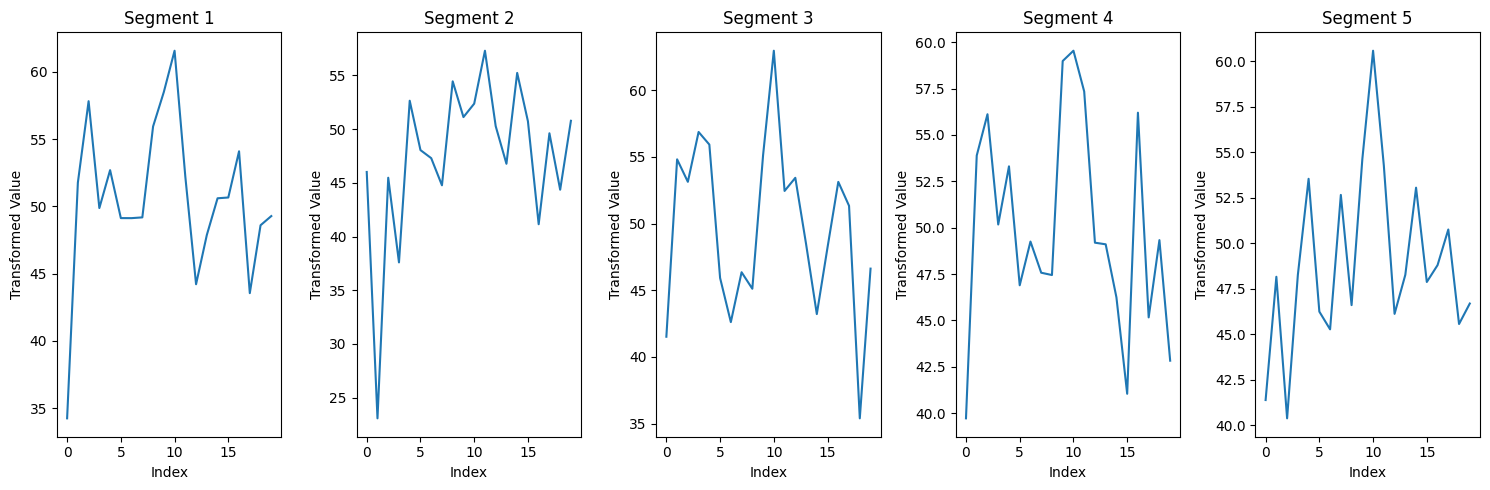

In [ ]:
import matplotlib.pyplot as plt
import random

def plot_random_peak_segments(arrays_list, n):
    # Randomly select n segments from the list
    random_segments = random.sample(arrays_list, n)

    # Plot each selected segment
    plt.figure(figsize=(15, 5))
    for i, segment in enumerate(random_segments):
        plt.subplot(1, n, i + 1)  # Create a subplot for each segment
        plt.plot(segment)
        plt.title(f'Segment {i + 1}')
        plt.xlabel('Index')
        plt.ylabel('Transformed Value')

    plt.tight_layout()
    plt.show()


n_to_plot = 5
plot_random_peak_segments(result, n_to_plot)

In [ ]:
import numpy as np

def generate_new_segments(original_segments, n, a, b):
    new_segments = []

    for i in range(len(original_segments)):
        # Select a random segment from the original list
        random_segment = original_segments[i]

        # Generate a random array of the same length as the segment, with values between a and b
        random_adjustment = np.random.uniform(a, b, len(random_segment))

        # Randomly decide whether to add or subtract the adjustment
        if np.random.rand() > 0.5:
            new_segment = random_segment + random_adjustment
        else:
            new_segment = random_segment + random_adjustment

        new_segments.append(new_segment)

    return new_segments


a = 0
b = 2
n_generated_segments = 6000

generated_segments = generate_new_segments(result, n_generated_segments, a, b)


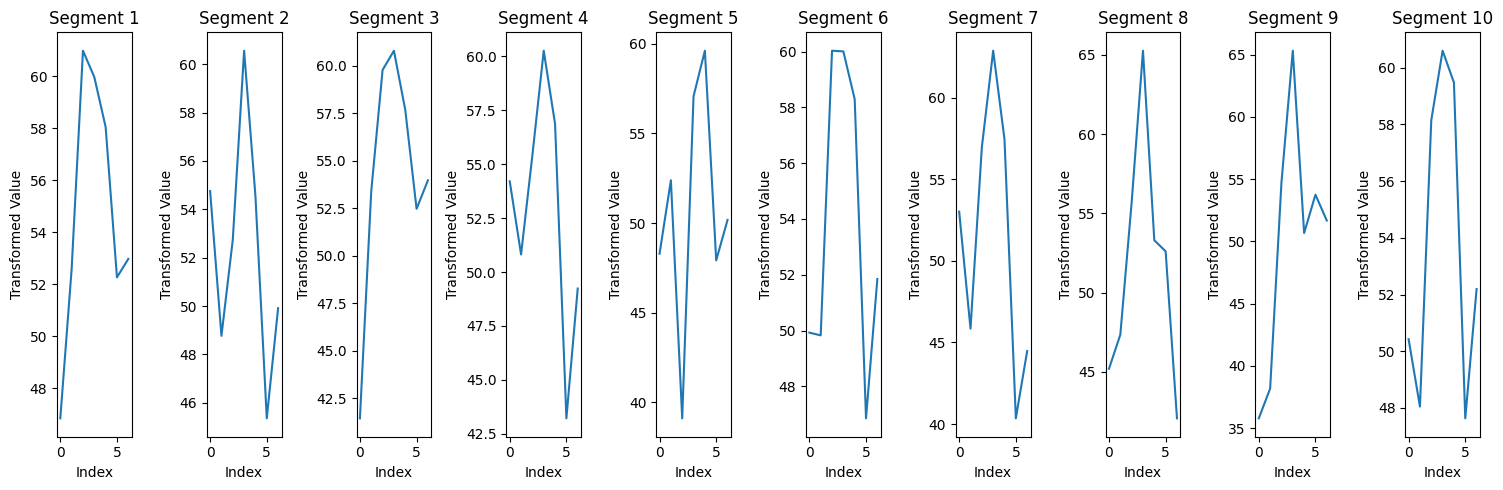

In [ ]:
plot_random_peak_segments(generated_segments, 10)

In [ ]:
len(generated_segments[1])

18

In [ ]:
import numpy as np
import pandas as pd
import os
import random

def load_files_from_directory(directory):
    data = []
    for filename in os.listdir(directory):
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            data.append(df['transformed_value'])
    return np.array(data)

def insert_generated_segments(directory, output_directory, generated_peak_segments, segment_length=20, target_frequencies=[50]):
    normal_data_files = load_files_from_directory(directory)
    target_frequencies = [(freq * 2 + 2) for freq in target_frequencies]

    for i, data in enumerate(normal_data_files):
        for target_frequency in target_frequencies:
            # Randomly select a peak segment
            generated_peak = random.choice(generated_peak_segments)

            start = max(0, target_frequency - segment_length // 2)
            end = min(len(data), start + segment_length)
            if end - start < segment_length:
                generated_peak = generated_peak[:end-start]

            data[start:end] = generated_peak.flatten()

        df = pd.DataFrame(data, columns=["transformed_value"])
        df.to_csv(os.path.join(output_directory, f'synt_anomalous_data_{i}.csv'), index=False)

    return normal_data_files

# Example usage
directory = '/content/To_gen_REAL_anomlies'
output_directory = '/content/Generated_Real_Anomalies_6'
anomalous_data = insert_generated_segments(directory, output_directory, generated_segments, segment_length=5, target_frequencies=[100])


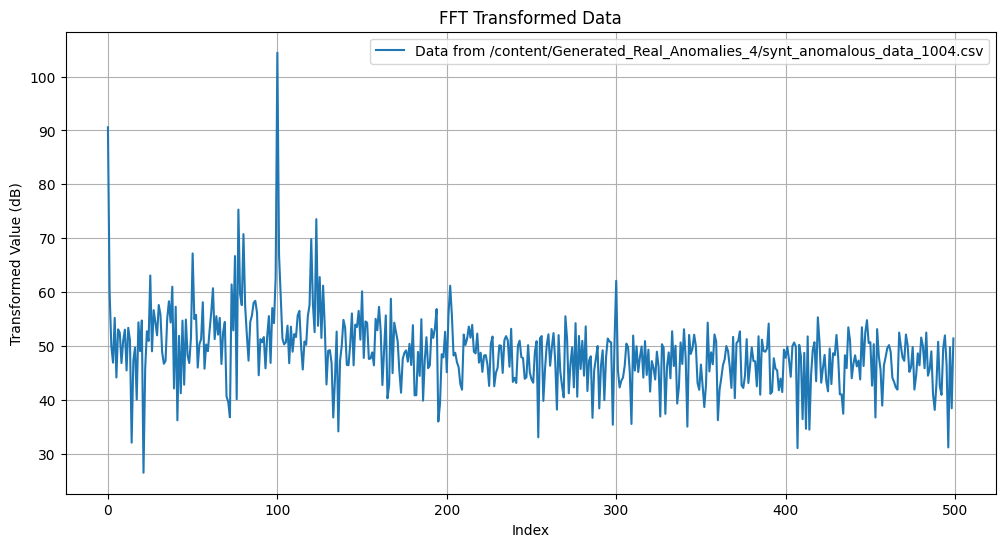

In [ ]:
plot_transformed_data('/content/Generated_Real_Anomalies_4/synt_anomalous_data_1004.csv')

In [ ]:
import shutil
import os

def zip_folder(folder_path, zip_path):
    shutil.make_archive(zip_path, 'zip', folder_path)

folder_path = '/content/Generated_Real_Anomalies_6'
zip_path = '/content/Generated_Real_Anomalies_6'

zip_folder(folder_path, zip_path)
